In [1]:
import pyspark

In [2]:
spark = SparkSession.builder \
    .appName("StockTweetForecasting") \
    .config("spark.pyspark.python", "/home/hduser/pyspark_env/bin/python") \
    .config("spark.pyspark.driver.python", "/home/hduser/pyspark_env/bin/python") \
    .config("spark.executorEnv.PYSPARK_PYTHON", "/home/hduser/pyspark_env/bin/python") \
    .getOrCreate()

26/06/03 22:03:39 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_date, count, avg
from pyspark.sql.functions import lower, regexp_replace, trim, length

spark = SparkSession.builder.appName("StockTweetForecasting").getOrCreate()

stock_tweets = spark.read.csv("hdfs:///stocks/raw_data/stocktweet.csv",header=True,inferSchema=True)

stock_tweets = stock_tweets.withColumn("date", to_date(col("date"), "dd/MM/yyyy"))

stock_tweets.printSchema()
stock_tweets.show(10, truncate=False)

root
 |-- id: string (nullable = true)
 |-- date: date (nullable = true)
 |-- ticker: string (nullable = true)
 |-- tweet: string (nullable = true)

+------------------------------------------------------------------+----------+------+-------------------------------------------------------------------------------------------------------------------------------------------+
|id                                                                |date      |ticker|tweet                                                                                                                                      |
+------------------------------------------------------------------+----------+------+-------------------------------------------------------------------------------------------------------------------------------------------+
|100001                                                            |2020-01-01|AMZN  |$AMZN Dow futures up by 100 points already 🥳                                        

In [4]:
import re
import html
import unicodedata
from pyspark.sql.functions import udf, col
from pyspark.sql.types import StringType

def clean_text(text):

    if text is None:
        return ""

    
    text = str(text) # Convert to string
    text = html.unescape(text) # Fix HTML entities
    text = unicodedata.normalize("NFKD", text) # Normalize unicode
    text = text.encode("ascii", "ignore").decode("ascii") # Remove corrupted unicode/emojis
    text = text.lower()  # Lowercase
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text) # Remove URLs
    text = re.sub(r"\$[A-Za-z]+", " ", text) # Remove ticker symbols
    text = re.sub(r"@[A-Za-z0-9_]+", " ", text) # Remove mentions
    text = re.sub(r"#", "", text) # Remove hashtags symbol only
    text = re.sub(r"\d+", " ", text) # Remove numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text) # Remove punctuation
    text = re.sub(r"\s+", " ", text).strip() # Remove extra spaces
    return text

In [5]:
text_udf = udf(clean_text, StringType())

cleaned_df = stock_tweets.withColumn(
    "clean_text",
    text_udf(col("tweet"))
)

selected_tickers = ["ABNB", "AMZN", "NKE", "GOOGL", "NFLX"]

cleaned_df = cleaned_df.filter(
    col("ticker").isin(selected_tickers)
)

cleaned_df.select("ticker", "clean_text").show(30, truncate=False)

cleaned_df.select(
    "ticker",
    "clean_text"
).show(30, truncate=False)

+------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|ticker|clean_text                                                                                                                                                                                              |
+------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|AMZN  |dow futures up by points already                                                                                                                                                                        |
|AMZN  |who ever shorted today will be deported from us if you are immigrants                                                                                   

In [6]:
#pip install vaderSentiment

In [7]:
ABNB = spark.read.csv(
    "hdfs:///stocks/raw_data/stockprice/ABNB.csv",
    header=True,
    inferSchema=True
)

AMZN = spark.read.csv(
    "hdfs:///stocks/raw_data/stockprice/AMZN.csv",
    header=True,
    inferSchema=True
)

NKE = spark.read.csv(
    "hdfs:///stocks/raw_data/stockprice/NKE.csv",
    header=True,
    inferSchema=True
)

GOOGL = spark.read.csv(
    "hdfs:///stocks/raw_data/stockprice/GOOGL.csv",
    header=True,
    inferSchema=True
)

NFLX = spark.read.csv(
    "hdfs:///stocks/raw_data/stockprice/NFLX.csv",
    header=True,
    inferSchema=True
)

In [8]:
spark.read.csv(
    "hdfs:///stocks/raw_data/stockprice/ABNB.csv",
    header=True,
    inferSchema=True
).show(5)

+----------+------------------+-----------------+------------------+------------------+------------------+--------+
|      Date|              Open|             High|               Low|             Close|         Adj Close|  Volume|
+----------+------------------+-----------------+------------------+------------------+------------------+--------+
|2020-12-10|             146.0|            165.0|            141.25| 144.7100067138672| 144.7100067138672|70447500|
|2020-12-11| 146.5500030517578|            151.5|135.10000610351562|            139.25|            139.25|26980800|
|2020-12-14|             135.0|135.3000030517578|125.16000366210938|             130.0|             130.0|16966100|
|2020-12-15|126.69000244140625|127.5999984741211|             121.5|124.80000305175781|124.80000305175781|10914400|
|2020-12-16|125.83000183105469|            142.0|124.91000366210938|137.99000549316406|137.99000549316406|20409600|
+----------+------------------+-----------------+------------------+----

In [9]:
from pyspark.sql.functions import col, to_date

ABNB = ABNB.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))
AMZN = AMZN.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))
NKE = NKE.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))
GOOGL = GOOGL.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))
NFLX = NFLX.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))

In [10]:
from pyspark.sql.functions import lit

ABNB = ABNB.withColumn("ticker", lit("ABNB"))
AMZN = AMZN.withColumn("ticker", lit("AMZN"))
NKE = NKE.withColumn("ticker", lit("NKE"))
GOOGL = GOOGL.withColumn("ticker", lit("GOOGL"))
NFLX = NFLX.withColumn("ticker", lit("NFLX"))

In [11]:
stock_prices = ABNB.union(AMZN) \
                   .union(NKE) \
                   .union(GOOGL) \
                   .union(NFLX)

stock_prices.show(300)

+----------+------------------+------------------+------------------+------------------+------------------+---------+------+
|      Date|              Open|              High|               Low|             Close|         Adj Close|   Volume|ticker|
+----------+------------------+------------------+------------------+------------------+------------------+---------+------+
|2020-12-10|             146.0|             165.0|            141.25| 144.7100067138672| 144.7100067138672| 70447500|  ABNB|
|2020-12-11| 146.5500030517578|             151.5|135.10000610351562|            139.25|            139.25| 26980800|  ABNB|
|2020-12-14|             135.0| 135.3000030517578|125.16000366210938|             130.0|             130.0| 16966100|  ABNB|
|2020-12-15|126.69000244140625| 127.5999984741211|             121.5|124.80000305175781|124.80000305175781| 10914400|  ABNB|
|2020-12-16|125.83000183105469|             142.0|124.91000366210938|137.99000549316406|137.99000549316406| 20409600|  ABNB|


In [12]:
final_data = stock_prices

final_data.show(10)

+----------+------------------+------------------+------------------+------------------+------------------+--------+------+
|      Date|              Open|              High|               Low|             Close|         Adj Close|  Volume|ticker|
+----------+------------------+------------------+------------------+------------------+------------------+--------+------+
|2020-12-10|             146.0|             165.0|            141.25| 144.7100067138672| 144.7100067138672|70447500|  ABNB|
|2020-12-11| 146.5500030517578|             151.5|135.10000610351562|            139.25|            139.25|26980800|  ABNB|
|2020-12-14|             135.0| 135.3000030517578|125.16000366210938|             130.0|             130.0|16966100|  ABNB|
|2020-12-15|126.69000244140625| 127.5999984741211|             121.5|124.80000305175781|124.80000305175781|10914400|  ABNB|
|2020-12-16|125.83000183105469|             142.0|124.91000366210938|137.99000549316406|137.99000549316406|20409600|  ABNB|
|2020-12

In [13]:
tweets = spark.read.csv(
    "hdfs:///stocks/raw_data/stocktweet.csv",
    header=True,
    inferSchema=True
)

tweets.show(5)

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|
|100004|01/01/2020|  TSLA|$TSLA happy new y...|
|100005|01/01/2020|  TSLA|"$TSLA haha just ...|
+------+----------+------+--------------------+
only showing top 5 rows



In [14]:
tweets.printSchema()

root
 |-- id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- ticker: string (nullable = true)
 |-- tweet: string (nullable = true)



In [15]:
stock_prices.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Adj Close: double (nullable = true)
 |-- Volume: integer (nullable = true)
 |-- ticker: string (nullable = false)



In [16]:
final_data = stock_prices
final_data.show()

+----------+------------------+------------------+------------------+------------------+------------------+--------+------+
|      Date|              Open|              High|               Low|             Close|         Adj Close|  Volume|ticker|
+----------+------------------+------------------+------------------+------------------+------------------+--------+------+
|2020-12-10|             146.0|             165.0|            141.25| 144.7100067138672| 144.7100067138672|70447500|  ABNB|
|2020-12-11| 146.5500030517578|             151.5|135.10000610351562|            139.25|            139.25|26980800|  ABNB|
|2020-12-14|             135.0| 135.3000030517578|125.16000366210938|             130.0|             130.0|16966100|  ABNB|
|2020-12-15|126.69000244140625| 127.5999984741211|             121.5|124.80000305175781|124.80000305175781|10914400|  ABNB|
|2020-12-16|125.83000183105469|             142.0|124.91000366210938|137.99000549316406|137.99000549316406|20409600|  ABNB|
|2020-12

# EDA

In [17]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lit, to_date, count, isnan, when, avg, min, max, stddev

spark = SparkSession.builder.appName("Stock_EDA").getOrCreate()

26/06/03 22:04:02 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [18]:
base_path = "hdfs:///stocks/raw_data/stockprice/"

ABNB = spark.read.csv(base_path + "ABNB.csv", header=True, inferSchema=True).withColumn("ticker", lit("ABNB"))
AMZN = spark.read.csv(base_path + "AMZN.csv", header=True, inferSchema=True).withColumn("ticker", lit("AMZN"))
NKE = spark.read.csv(base_path + "NKE.csv", header=True, inferSchema=True).withColumn("ticker", lit("NKE"))
GOOGL = spark.read.csv(base_path + "GOOGL.csv", header=True, inferSchema=True).withColumn("ticker", lit("GOOGL"))
NFLX = spark.read.csv(base_path + "NFLX.csv", header=True, inferSchema=True).withColumn("ticker", lit("NFLX"))

In [19]:
stock_prices = ABNB.unionByName(AMZN) \
                   .unionByName(NKE) \
                   .unionByName(GOOGL) \
                   .unionByName(NFLX)

stock_prices.show(10)

+----------+------------------+------------------+------------------+------------------+------------------+--------+------+
|      Date|              Open|              High|               Low|             Close|         Adj Close|  Volume|ticker|
+----------+------------------+------------------+------------------+------------------+------------------+--------+------+
|2020-12-10|             146.0|             165.0|            141.25| 144.7100067138672| 144.7100067138672|70447500|  ABNB|
|2020-12-11| 146.5500030517578|             151.5|135.10000610351562|            139.25|            139.25|26980800|  ABNB|
|2020-12-14|             135.0| 135.3000030517578|125.16000366210938|             130.0|             130.0|16966100|  ABNB|
|2020-12-15|126.69000244140625| 127.5999984741211|             121.5|124.80000305175781|124.80000305175781|10914400|  ABNB|
|2020-12-16|125.83000183105469|             142.0|124.91000366210938|137.99000549316406|137.99000549316406|20409600|  ABNB|
|2020-12

In [20]:
stock_prices.printSchema()
stock_prices.describe().show()
stock_prices.count()

root
 |-- Date: date (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Adj Close: double (nullable = true)
 |-- Volume: integer (nullable = true)
 |-- ticker: string (nullable = false)



26/06/03 22:04:04 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+------------------+------------------+------------------+------------------+--------------------+------+
|summary|              Open|              High|               Low|             Close|         Adj Close|              Volume|ticker|
+-------+------------------+------------------+------------------+------------------+------------------+--------------------+------+
|  count|              1031|              1031|              1031|              1031|              1031|                1031|  1031|
|   mean|189.35049027776856| 192.4516494077577|186.32689610508086|189.52595670239424|188.61383644200203|  3.78168935014549E7|  NULL|
| stddev|152.79033750091668|155.63455600221457| 149.9919498788437|152.99703797462874| 153.4885667234985|4.3088415122295536E7|  NULL|
|    min| 52.81850051879883| 53.34550094604492| 50.44350051879883| 52.70650100708008| 52.70650100708008|             1144000|  ABNB|
|    max|   567.97998046875| 575.3699951171875|             541.0| 55

1031

In [21]:
stock_prices = stock_prices.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))

stock_prices.select("Date", "ticker").show(10)

+----------+------+
|      Date|ticker|
+----------+------+
|2020-12-10|  ABNB|
|2020-12-11|  ABNB|
|2020-12-14|  ABNB|
|2020-12-15|  ABNB|
|2020-12-16|  ABNB|
|2020-12-17|  ABNB|
|2020-12-18|  ABNB|
|2020-12-21|  ABNB|
|2020-12-22|  ABNB|
|2020-12-23|  ABNB|
+----------+------+
only showing top 10 rows



In [22]:
missing_values = stock_prices.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in stock_prices.columns
])

missing_values.show()

+----+----+----+---+-----+---------+------+------+
|Date|Open|High|Low|Close|Adj Close|Volume|ticker|
+----+----+----+---+-----+---------+------+------+
|   0|   0|   0|  0|    0|        0|     0|     0|
+----+----+----+---+-----+---------+------+------+



In [23]:
ABNB = spark.read.csv("hdfs:///stocks/raw_data/stockprice/ABNB.csv", header=True, inferSchema=True)
AMZN = spark.read.csv("hdfs:///stocks/raw_data/stockprice/AMZN.csv", header=True, inferSchema=True)
NKE = spark.read.csv("hdfs:///stocks/raw_data/stockprice/NKE.csv", header=True, inferSchema=True)
GOOGL = spark.read.csv("hdfs:///stocks/raw_data/stockprice/GOOGL.csv", header=True, inferSchema=True)
NFLX = spark.read.csv("hdfs:///stocks/raw_data/stockprice/NFLX.csv", header=True, inferSchema=True)

In [24]:
from pyspark.sql.functions import lit

ABNB = ABNB.withColumn("ticker", lit("ABNB"))
AMZN = AMZN.withColumn("ticker", lit("AMZN"))
NKE = NKE.withColumn("ticker", lit("NKE"))
GOOGL = GOOGL.withColumn("ticker", lit("GOOGL"))
NFLX = NFLX.withColumn("ticker", lit("NFLX"))

stock_prices = ABNB.unionByName(AMZN) \
                   .unionByName(NKE) \
                   .unionByName(GOOGL) \
                   .unionByName(NFLX)

stock_prices.show(10)

+----------+------------------+------------------+------------------+------------------+------------------+--------+------+
|      Date|              Open|              High|               Low|             Close|         Adj Close|  Volume|ticker|
+----------+------------------+------------------+------------------+------------------+------------------+--------+------+
|2020-12-10|             146.0|             165.0|            141.25| 144.7100067138672| 144.7100067138672|70447500|  ABNB|
|2020-12-11| 146.5500030517578|             151.5|135.10000610351562|            139.25|            139.25|26980800|  ABNB|
|2020-12-14|             135.0| 135.3000030517578|125.16000366210938|             130.0|             130.0|16966100|  ABNB|
|2020-12-15|126.69000244140625| 127.5999984741211|             121.5|124.80000305175781|124.80000305175781|10914400|  ABNB|
|2020-12-16|125.83000183105469|             142.0|124.91000366210938|137.99000549316406|137.99000549316406|20409600|  ABNB|
|2020-12

In [25]:
#pip install setuptools pandas

In [26]:
final_pd = stock_prices.toPandas()

In [27]:
final_pd = final_data.toPandas()

final_pd.head()

,Date,Open,High,Low,Close,Adj Close,Volume,ticker
0,2020-12-10,146.000000,165.000000,141.250000,144.710007,144.710007,70447500,ABNB
1,2020-12-11,146.550003,151.500000,135.100006,139.250000,139.250000,26980800,ABNB
2,2020-12-14,135.000000,135.300003,125.160004,130.000000,130.000000,16966100,ABNB
3,2020-12-15,126.690002,127.599998,121.500000,124.800003,124.800003,10914400,ABNB
4,2020-12-16,125.830002,142.000000,124.910004,137.990005,137.990005,20409600,ABNB


In [28]:
print(final_pd.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'ticker'],
      dtype='str')


In [29]:
final_pd.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
ticker       0
dtype: int64

In [30]:
final_pd["ticker"].value_counts()

ticker
AMZN     254
NKE      254
GOOGL    254
NFLX     254
ABNB      15
Name: count, dtype: int64

In [31]:
print("Start Date:", final_pd["Date"].min())
print("End Date:", final_pd["Date"].max())

Start Date: 2019-12-31
End Date: 2020-12-31


In [32]:
import pandas as pd

final_pd["Date"] = pd.to_datetime(final_pd["Date"])
df = final_pd.copy()

df = df.sort_values(["ticker", "Date"])

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,ticker
0,2020-12-10,146.000000,165.000000,141.250000,144.710007,144.710007,70447500,ABNB
1,2020-12-11,146.550003,151.500000,135.100006,139.250000,139.250000,26980800,ABNB
2,2020-12-14,135.000000,135.300003,125.160004,130.000000,130.000000,16966100,ABNB
3,2020-12-15,126.690002,127.599998,121.500000,124.800003,124.800003,10914400,ABNB
4,2020-12-16,125.830002,142.000000,124.910004,137.990005,137.990005,20409600,ABNB


In [33]:
df.isnull().sum()
df.describe()
df["ticker"].value_counts()

ticker
AMZN     254
GOOGL    254
NFLX     254
NKE      254
ABNB      15
Name: count, dtype: int64

In [34]:
#This line helps to make columns for each company
tickers = ["ABNB", "AMZN", "GOOGL", "NKE", "NFLX"]

company_data = {}

for ticker in tickers:
    company_data[ticker] = df[df["ticker"] == ticker].copy()
    company_data[ticker] = company_data[ticker].sort_values("Date")

company_data

{'ABNB':          Date        Open        High         Low       Close   Adj Close  \
 0  2020-12-10  146.000000  165.000000  141.250000  144.710007  144.710007   
 1  2020-12-11  146.550003  151.500000  135.100006  139.250000  139.250000   
 2  2020-12-14  135.000000  135.300003  125.160004  130.000000  130.000000   
 3  2020-12-15  126.690002  127.599998  121.500000  124.800003  124.800003   
 4  2020-12-16  125.830002  142.000000  124.910004  137.990005  137.990005   
 5  2020-12-17  143.000000  152.449997  142.669998  147.050003  147.050003   
 6  2020-12-18  150.449997  159.000000  150.300003  157.300003  157.300003   
 7  2020-12-21  155.309998  172.000000  145.110001  163.020004  163.020004   
 8  2020-12-22  170.000000  174.970001  161.050003  163.190002  163.190002   
 9  2020-12-23  162.813995  168.250000  155.500000  158.009995  158.009995   
 10 2020-12-24  159.160004  162.789993  154.112000  154.839996  154.839996   
 11 2020-12-28  158.600006  163.639999  147.520004  149.

In [35]:
#pip install matplotlib

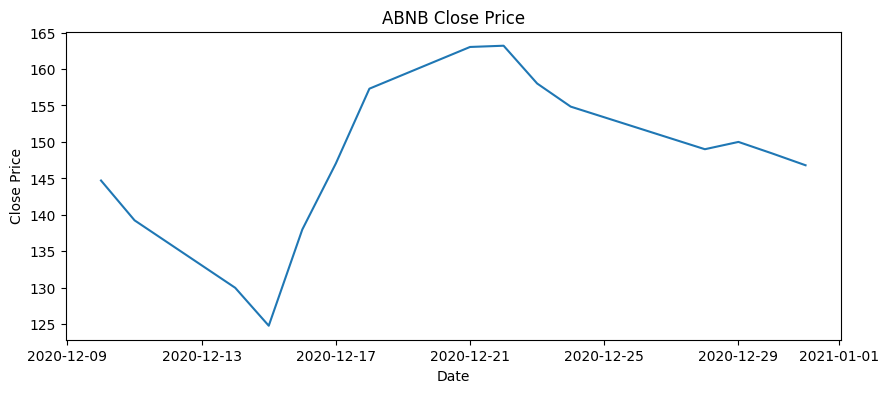

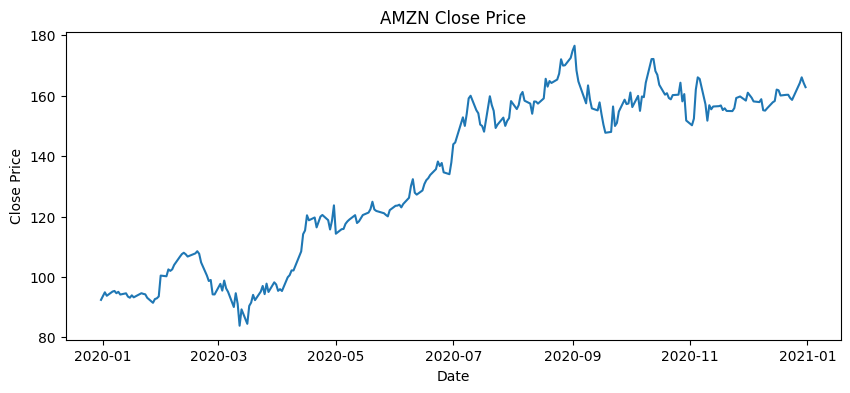

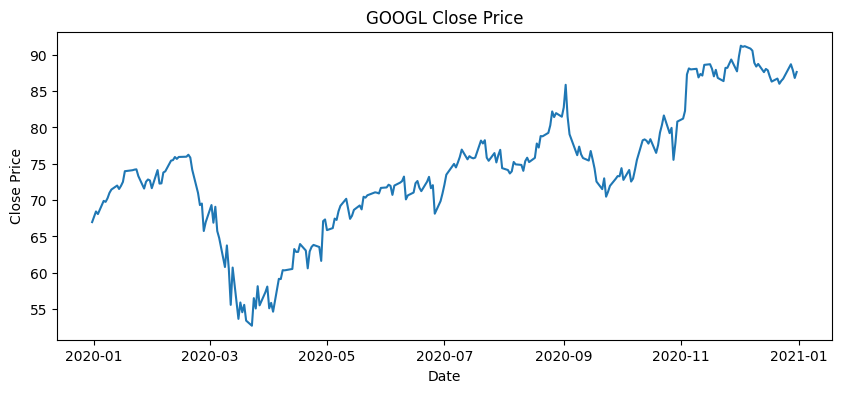

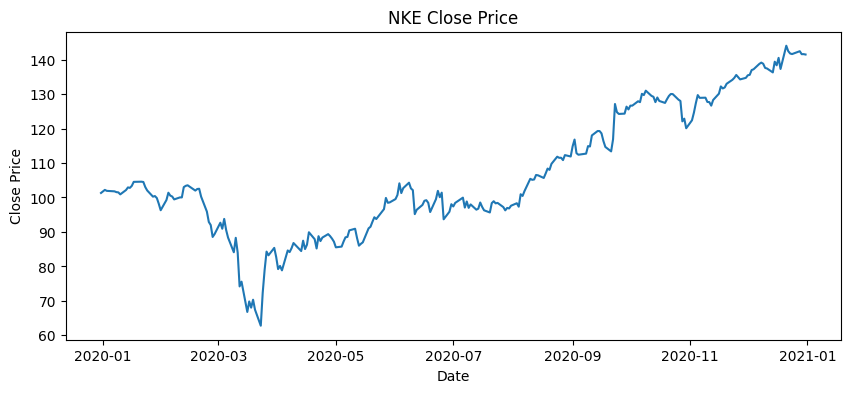

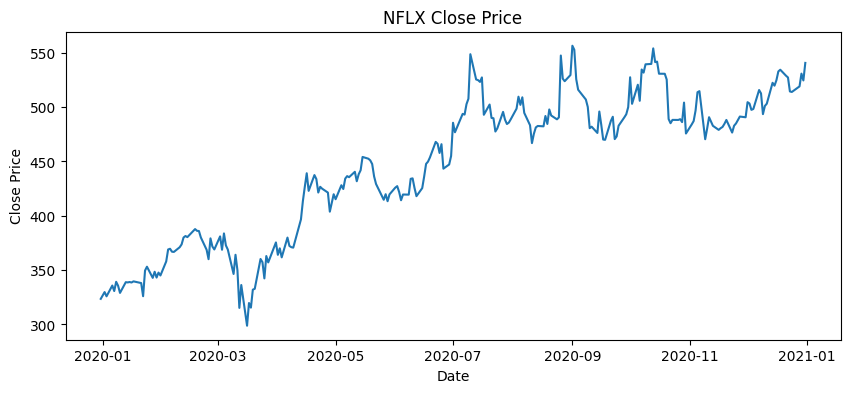

In [36]:
import matplotlib.pyplot as plt

for ticker in tickers:
    temp = company_data[ticker]

    plt.figure(figsize=(10, 4))
    plt.plot(temp["Date"], temp["Close"])
    plt.title(f"{ticker} Close Price")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.show()

## Correlation matrix

In [37]:
for ticker in tickers:
    temp = company_data[ticker]

    print(f"\n{ticker} Correlation Matrix")
    
    corr_matrix = temp[["Open", "High", "Low", "Close", "Volume"]].corr()
    print(corr_matrix)


ABNB Correlation Matrix
            Open      High       Low     Close    Volume
Open    1.000000  0.888606  0.950964  0.868776 -0.232588
High    0.888606  1.000000  0.873488  0.914289  0.102068
Low     0.950964  0.873488  1.000000  0.916573 -0.236691
Close   0.868776  0.914289  0.916573  1.000000 -0.187958
Volume -0.232588  0.102068 -0.236691 -0.187958  1.000000

AMZN Correlation Matrix
            Open      High       Low     Close    Volume
Open    1.000000  0.998280  0.997883  0.995973 -0.153910
High    0.998280  1.000000  0.997437  0.998058 -0.129278
Low     0.997883  0.997437  1.000000  0.998154 -0.180392
Close   0.995973  0.998058  0.998154  1.000000 -0.154858
Volume -0.153910 -0.129278 -0.180392 -0.154858  1.000000

GOOGL Correlation Matrix
            Open      High       Low     Close    Volume
Open    1.000000  0.996503  0.995792  0.991446 -0.526778
High    0.996503  1.000000  0.995355  0.995464 -0.506435
Low     0.995792  0.995355  1.000000  0.996406 -0.559974
Close   0.99

In [38]:
for ticker in tickers:
    temp = company_data[ticker]

    cols = ["Open", "High", "Low", "Close", "Volume"]

    if "avg_sentiment" in temp.columns:
        cols.append("avg_sentiment")

    print(f"\n{ticker} Correlation Matrix")
    print(temp[cols].corr())


ABNB Correlation Matrix
            Open      High       Low     Close    Volume
Open    1.000000  0.888606  0.950964  0.868776 -0.232588
High    0.888606  1.000000  0.873488  0.914289  0.102068
Low     0.950964  0.873488  1.000000  0.916573 -0.236691
Close   0.868776  0.914289  0.916573  1.000000 -0.187958
Volume -0.232588  0.102068 -0.236691 -0.187958  1.000000

AMZN Correlation Matrix
            Open      High       Low     Close    Volume
Open    1.000000  0.998280  0.997883  0.995973 -0.153910
High    0.998280  1.000000  0.997437  0.998058 -0.129278
Low     0.997883  0.997437  1.000000  0.998154 -0.180392
Close   0.995973  0.998058  0.998154  1.000000 -0.154858
Volume -0.153910 -0.129278 -0.180392 -0.154858  1.000000

GOOGL Correlation Matrix
            Open      High       Low     Close    Volume
Open    1.000000  0.996503  0.995792  0.991446 -0.526778
High    0.996503  1.000000  0.995355  0.995464 -0.506435
Low     0.995792  0.995355  1.000000  0.996406 -0.559974
Close   0.99

## SARIMAX

In [39]:
#pip show statsmodels

In [40]:
#pip show scikit-learn

In [41]:
sarimax_results = {}

In [42]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

In [43]:
for ticker in tickers:
    temp = company_data[ticker].copy()
    temp = temp.sort_values("Date")

    cols = ["Close", "Open", "High", "Low", "Volume"]

    for col in cols:
        temp[col] = pd.to_numeric(temp[col], errors="coerce")

    temp = temp.replace([np.inf, -np.inf], np.nan)
    temp = temp.dropna(subset=cols)

    print("\n", ticker)
    print("Rows after cleaning:", len(temp))

    if len(temp) < 20:
        print("Not enough data for SARIMAX")
        continue

    y = temp["Close"]
    X = temp[["Open", "High", "Low", "Volume"]]

    train_size = int(len(temp) * 0.8)

    y_train = y.iloc[:train_size]
    y_test = y.iloc[train_size:]

    X_train = X.iloc[:train_size]
    X_test = X.iloc[train_size:]

    model = SARIMAX(
        y_train,
        exog=X_train,
        order=(1, 1, 1),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(disp=False)

    predictions = fitted_model.forecast(
        steps=len(y_test),
        exog=X_test
    )

    predictions = pd.Series(predictions, index=y_test.index)

    check = pd.DataFrame({
        "actual": y_test.values,
        "predicted": predictions.values
    }).dropna()

    print("Rows for metrics:", len(check))

    if len(check) == 0:
        print("No valid prediction rows")
        continue

    mae = mean_absolute_error(check["actual"], check["predicted"])
    rmse = np.sqrt(mean_squared_error(check["actual"], check["predicted"]))

    print("MAE:", mae)
    print("RMSE:", rmse)
    
    future_exog = X.tail(5)

future_forecast = fitted_model.forecast(
    steps=5,
    exog=future_exog
)

print("1-Day Forecast:", round(future_forecast.iloc[0], 2))
print("3-Day Forecast:", round(future_forecast.iloc[2], 2))
print("5-Day Forecast:", round(future_forecast.iloc[4], 2))


 ABNB
Rows after cleaning: 15
Not enough data for SARIMAX

 AMZN
Rows after cleaning: 254


/home/hduser/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/hduser/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/hduser/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/hduser/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beg

Rows for metrics: 36
MAE: 3.690752118634828
RMSE: 4.391057901800881

 GOOGL
Rows after cleaning: 254


/home/hduser/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/hduser/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/home/hduser/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/hduser/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model

Rows for metrics: 0
No valid prediction rows

 NKE
Rows after cleaning: 254


/home/hduser/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/hduser/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/home/hduser/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/hduser/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model

Rows for metrics: 0
No valid prediction rows

 NFLX
Rows after cleaning: 254
Rows for metrics: 0
No valid prediction rows
1-Day Forecast: 256.54
3-Day Forecast: 279.08
5-Day Forecast: 267.16


/home/hduser/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/hduser/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/home/hduser/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/hduser/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
 

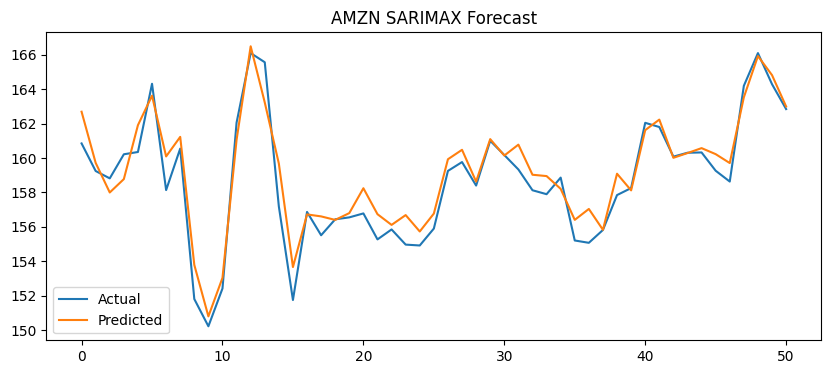

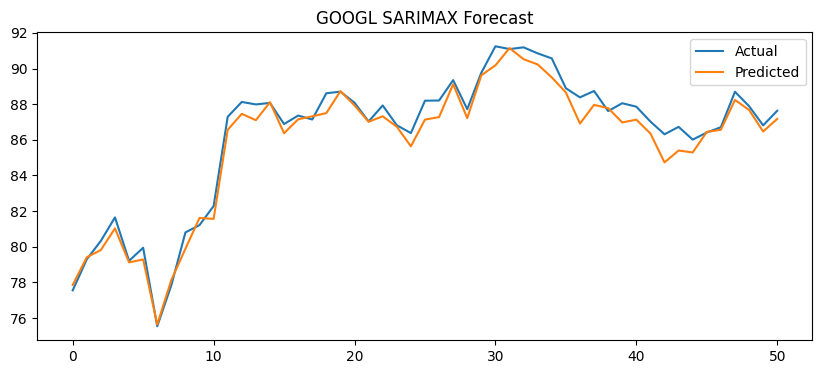

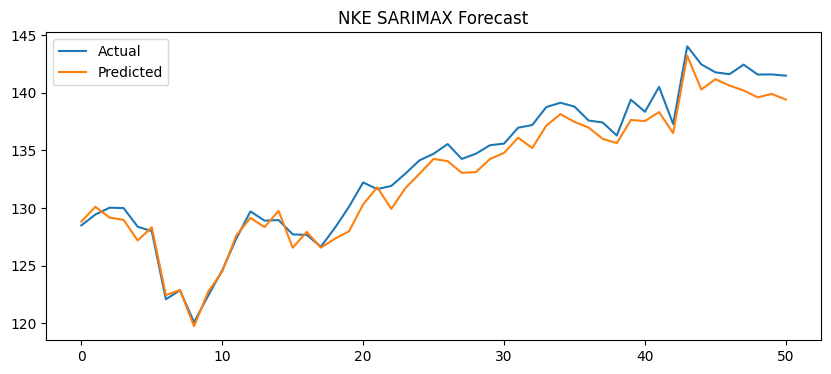

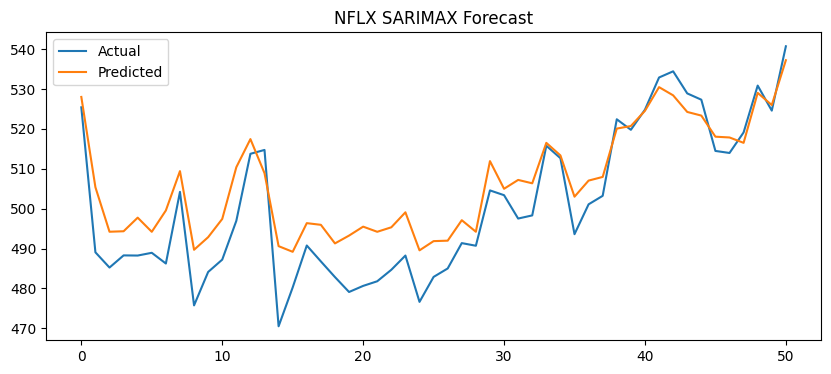

In [51]:
for ticker in sarimax_results.keys():

    plt.figure(figsize=(10,4))

    plt.plot(
        sarimax_results[ticker]["actual"].values,
        label="Actual"
    )

    plt.plot(
        sarimax_results[ticker]["predicted"].values,
        label="Predicted"
    )

    plt.title(f"{ticker} SARIMAX Forecast")
    plt.legend()
    plt.show()

In [53]:
print(company_data["ABNB"].shape)

(15, 8)
